# BRDF normalization as an ONNX model with `predict_onnx` (no UDF)

This notebook shows how to run custom per-pixel math on openEO **without a Python UDF**:
write the math with numpy-style code in [ndonnx](https://github.com/Quantco/ndonnx), export it
to an ONNX file, and run it on the backend with the `predict_onnx` process.

The example is a real harmonization step: the **Roy et al. (2016/2017) c-factor BRDF
normalization** from [sen2like](https://github.com/senbox-org/sen2like/blob/master/sen2like/sen2like/s2l_processes/S2L_Nbar.py).
It converts Sentinel-2 surface reflectance to *nadir BRDF-adjusted reflectance* (NBAR):
what each pixel would look like if the satellite had looked straight down and the sun
had been at a fixed reference angle. This removes the brightness differences between
dates that come only from viewing and sun geometry.

### Python UDF vs `predict_onnx`

| | Python UDF | `predict_onnx` |
|---|---|---|
| What you send | Python source code | An `.onnx` file at a public URL |
| Runs in | Python sandbox on the backend | ONNX Runtime inside the backend |
| Extra dependencies | Must exist on the backend, or be shipped as an archive | None |
| Test before running a job | Hard: you must reproduce the backend's xarray chunks | Easy: run the same `.onnx` file locally with `onnxruntime` |
| Flexibility | Any Python | Only what ONNX can express; fixed tile size; no `context` |

The workflow:

1. write the model with ndonnx and export it to ONNX
2. test it locally against a plain numpy implementation
3. publish the `.onnx` file at a URL
4. run it on openEO with `predict_onnx`
5. run the same algorithm as a Python UDF and check both give the same result

> `predict_onnx` is an **experimental** process. This notebook targets the
> [Copernicus Data Space Ecosystem](https://dataspace.copernicus.eu/) openEO backend.

## Requirements

```
pip install openeo ndonnx "onnxruntime>=1.18" rasterio matplotlib
```

ndonnx needs `numpy>=2`. The file `roy_brdf.py` next to this notebook holds the plain numpy
version of the algorithm (used as the reference) and the Python UDF version.

In [1]:
import glob
import urllib.request

import matplotlib.pyplot as plt
import ndonnx as ndx
import numpy as np
import onnx
import onnxruntime as ort
import openeo
import rasterio

import roy_brdf  # numpy reference + UDF entrypoint (next to this notebook)

## 1. Write the model with ndonnx

ndonnx implements the [Python array API](https://data-apis.org/array-api/) on top of ONNX.
You write ordinary numpy-style code (`ndx.sin`, `ndx.sqrt`, `ndx.where`); ndonnx records the
operations and turns them into an ONNX graph.

### The input/output contract

`predict_onnx` passes the model one tile at a time as a `(bands, y, x)` array. Bands are
matched **by position**, not by name, so the order below is part of the model.

| channel | content |
|---|---|
| 0-5 | reflectance `B02 B03 B04 B8A B11 B12` |
| 6 | `sunZenithAngles` [deg] |
| 7 | `viewZenithMean` [deg] |
| 8 | `sunAzimuthAngles` [deg] |
| 9 | `viewAzimuthMean` [deg] |
| 10 | `theta_s`: the per-scene reference sun zenith [deg] |

The output is the corrected reflectance for the 6 bands, in the same order.

`theta_s` is an input channel because `predict_onnx` has no `context` parameter: any
per-scene value has to travel as a band.

In [2]:
BAND_ORDER = ["B02", "B03", "B04", "B8A", "B11", "B12"]
ANGLE_ORDER = ["sunZenithAngles", "viewZenithMean", "sunAzimuthAngles", "viewAzimuthMean"]
N_IN = len(BAND_ORDER) + len(ANGLE_ORDER) + 1  # +1 for theta_s

# Roy et al. (2017) Table 1: (f_iso, f_geo, f_vol) per band. Shared with the numpy reference.
COEF = np.array([roy_brdf.ROY_COEF[b] for b in BAND_ORDER], dtype=np.float32)
CLIP_FACTOR = roy_brdf.CLIP_FACTOR  # sen2like limits the correction to +/-20%
D2R = np.pi / 180.0

The two BRDF kernels describe how a surface scatters light: `kgeo` models shadows cast by
objects (geometric), `kvol` models scattering inside a canopy (volumetric). They are
line-by-line translations of `roy_brdf.kgeo_li_sparse` and `roy_brdf.kvol_ross_thick`, with
`np.` replaced by `ndx.`.

> **Note on the volumetric kernel.** Like sen2like, `kvol` uses Roujean's scaling,
> `4/(3π)·(…) − 1/3`, which is the MODIS Ross-Thick kernel (Lucht et al., 2000, eq. 38:
> `(…) − π/4`) multiplied by 4/(3π). The Roy coefficients were derived with the MODIS form,
> so this version applies a correction about 1-2% weaker than the published method. We keep
> it to reproduce sen2like exactly.

In [3]:
def kgeo_li_sparse(sza_deg, vza_deg, dphi_deg):
    # Li-Sparse geometric kernel (h/b = 2, b/r = 1; atan(tan(.)) is kept to mirror the reference).
    ts_p = ndx.atan(ndx.tan(sza_deg * D2R))
    tv_p = ndx.atan(ndx.tan(vza_deg * D2R))
    phi = dphi_deg * D2R

    cos_zeta_p = ndx.cos(ts_p) * ndx.cos(tv_p) + ndx.sin(ts_p) * ndx.sin(tv_p) * ndx.cos(phi)
    tan_ts, tan_tv = ndx.tan(ts_p), ndx.tan(tv_p)
    d = ndx.sqrt(tan_ts * tan_ts + tan_tv * tan_tv - 2.0 * tan_ts * tan_tv * ndx.cos(phi))
    sec_s, sec_v = 1.0 / ndx.cos(ts_p), 1.0 / ndx.cos(tv_p)

    tps = tan_ts * tan_tv * ndx.sin(phi)
    cos_t = 2.0 * ndx.sqrt(d * d + tps * tps) / (sec_s + sec_v)
    cos_t = ndx.clip(cos_t, -1.0, 1.0)  # keep acos in its domain
    sin_t = ndx.sqrt(1.0 - cos_t * cos_t)
    t = ndx.acos(cos_t)

    overlap = (1.0 / np.pi) * (t - sin_t * cos_t) * (sec_s + sec_v)
    return overlap - sec_s - sec_v + 0.5 * (1.0 + cos_zeta_p) * sec_s * sec_v


def kvol_ross_thick(sza_deg, vza_deg, dphi_deg):
    # Ross-Thick volumetric kernel.
    ts, tv, phi = sza_deg * D2R, vza_deg * D2R, dphi_deg * D2R
    cos_zeta = ndx.cos(ts) * ndx.cos(tv) + ndx.sin(ts) * ndx.sin(tv) * ndx.cos(phi)
    zeta = ndx.acos(ndx.clip(cos_zeta, -1.0, 1.0))
    numerator = (np.pi / 2.0 - zeta) * ndx.cos(zeta) + ndx.sin(zeta)
    return (4.0 / (3.0 * np.pi)) * numerator / (ndx.cos(tv) + ndx.cos(ts)) - 1.0 / 3.0

Now the full model. The **c-factor** is the ratio of the BRDF model at the reference
geometry (sun at `theta_s`, sensor straight down) to the BRDF model at the actual geometry.
Multiplying the reflectance by it gives NBAR.

Three details are dictated by the backend, not by the math:

- **float64 in and out, float32 inside.** The backend delivers Sentinel-2 tiles as float64,
  and the model's input type must match. The trigonometric operators (`Tan`, `Atan`, `Acos`)
  only have float32 implementations in common ONNX Runtime builds, so we cast at the edges.
- **`maximum`/`minimum` instead of `clip` for the +/-20% limit.** The limits differ per
  pixel, and ONNX `Clip` only accepts single numbers as limits.
- **Fixed tile size.** The model is built for 32x32 tiles; the backend cuts the datacube
  into tiles of the size the model declares.

One ndonnx detail: indexing must name every axis (`x[6, :, :]`, not `x[6]`).

In [4]:
def roy_nbar(x):
    x32 = x.astype(ndx.float32)
    n = len(BAND_ORDER)
    rho = x32[0:n, :, :]
    sza, vza = x32[n, :, :], x32[n + 1, :, :]
    dphi = x32[n + 2, :, :] - x32[n + 3, :, :]
    theta_s = x32[n + 4, :, :]
    zero = theta_s * 0.0

    def add_band_axis(a):  # (y, x) -> (1, y, x), to broadcast against the 6 bands
        return ndx.reshape(a, (1,) + a.shape)

    kgeo_in, kvol_in = add_band_axis(kgeo_li_sparse(sza, vza, dphi)), add_band_axis(kvol_ross_thick(sza, vza, dphi))
    kgeo_ref, kvol_ref = add_band_axis(kgeo_li_sparse(theta_s, zero, zero)), add_band_axis(kvol_ross_thick(theta_s, zero, zero))

    coef = ndx.asarray(COEF)
    f_iso, f_geo, f_vol = (ndx.reshape(coef[:, i : i + 1], (n, 1, 1)) for i in range(3))

    c = (f_iso + f_geo * kgeo_ref + f_vol * kvol_ref) / (f_iso + f_geo * kgeo_in + f_vol * kvol_in)

    out = ndx.minimum(ndx.maximum(c * rho, (1.0 - CLIP_FACTOR) * rho), (1.0 + CLIP_FACTOR) * rho)
    out = ndx.where(rho <= 0.0, ndx.zeros_like(out), out)  # no-data stays 0
    return out.astype(ndx.float64)


def build_model(height=32, width=32):
    x = ndx.argument(shape=(N_IN, height, width), dtype=ndx.float64)
    return ndx.build({"x": x}, {"output": roy_nbar(x)})

## 2. Export and test locally

`onnx.checker` catches malformed graphs. Then we run the exported file with `onnxruntime`
(the same engine the backend uses) and compare it with the numpy reference on random
inputs. Nothing here touches openEO, so it costs no credits.

In [5]:
model = build_model(32, 32)
onnx.checker.check_model(model)
onnx.save(model, "roy_brdf_ndonnx.onnx")
print(f"{len(model.graph.node)} nodes, opset {model.opset_import[0].version}, IR {model.ir_version}")

310 nodes, opset 21, IR 8


In [6]:
def run_onnx(path, x):
    session = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    return session.run(None, {"x": x})[0]


def random_input(seed=0, theta_s=40.0):
    rng = np.random.default_rng(seed)
    x = np.empty((N_IN, 32, 32))
    x[0:6] = rng.uniform(100, 5000, (6, 32, 32))  # reflectance (scaled, as delivered by the backend)
    x[6] = rng.uniform(20, 60, (32, 32))           # sun zenith
    x[7] = rng.uniform(0, 10, (32, 32))            # view zenith
    x[8] = rng.uniform(100, 200, (32, 32))         # sun azimuth
    x[9] = rng.uniform(0, 360, (32, 32))           # view azimuth
    x[10] = theta_s
    return x


x = random_input()
got = run_onnx("roy_brdf_ndonnx.onnx", x)
ref = np.stack([roy_brdf.nbar(x[i], x[6], x[7], x[8] - x[9], roy_brdf.ROY_COEF[b], sza_norm=x[10])
                for i, b in enumerate(BAND_ORDER)])
rel = np.abs(got - ref).max() / np.abs(ref).max()
print(f"output {got.dtype} {got.shape}, max relative difference vs numpy: {rel:.1e}")
assert got.dtype == np.float64 and got.shape == (6, 32, 32)
assert rel < 1e-5  # float32 trigonometry inside

# Sanity check: if the actual geometry already equals the reference, nothing changes.
x_id = random_input(theta_s=35.0)
x_id[6], x_id[7], x_id[8], x_id[9] = 35.0, 0.0, 0.0, 0.0
assert np.allclose(run_onnx("roy_brdf_ndonnx.onnx", x_id), x_id[0:6], rtol=1e-5)
print("identity check OK")

output float64 (6, 32, 32), max relative difference vs numpy: 2.4e-07
identity check OK


## 3. Publish the model

The backend downloads the model from a URL, so the `.onnx` file must be publicly reachable
(a GitHub repository, a public S3 bucket, ...). Pin the URL to a commit or tag rather than a
branch, so the notebook keeps working if the file changes later.

Here we use a copy published in
[minaskar/openeo-brdf-onnx](https://github.com/minaskar/openeo-brdf-onnx), and check that it
gives the same results as the model we just built.

In [7]:
MODEL_URL = (
    "https://raw.githubusercontent.com/minaskar/openeo-brdf-onnx/"
    "ac274804f4b3c3e1e9dcc2eb87caa77565cdd78a/roy_brdf_ndonnx.onnx"
)

urllib.request.urlretrieve(MODEL_URL, "published.onnx")
# Same results up to float32 rounding (the published file was built with a slightly
# different operation order).
assert np.allclose(run_onnx("published.onnx", x), got, rtol=1e-6)
print("published model matches the local build")

published model matches the local build


## 4. Run it on openEO with `predict_onnx`

From here on we use the backend. The area is small and the period short, to keep the jobs
cheap.

In [8]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [9]:
spatial_extent = {"west": 5.05, "south": 51.21, "east": 5.10, "north": 51.23, "crs": "EPSG:4326"}
temporal_extent = ["2022-05-01", "2022-05-15"]

# The reference sun zenith depends only on the scene-centre latitude (sen2like eq. 4).
scene_center_lat = (spatial_extent["south"] + spatial_extent["north"]) / 2
theta_s = float(roy_brdf.mean_sun_zenith(scene_center_lat))
print(f"theta_s = {theta_s:.2f} deg")

# Band order here IS the model's channel order. Do not reorder.
cube = connection.load_collection(
    "SENTINEL2_L2A",
    bands=BAND_ORDER + ANGLE_ORDER,
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    max_cloud_cover=50,
)

theta_s = 52.76 deg


`theta_s` becomes the 11th band: a constant image, added after the 10 loaded bands.

In [10]:
theta_band = cube.reduce_dimension(dimension="bands", reducer="first") * 0 + theta_s
theta_band = theta_band.add_dimension(name="bands", label="theta_s", type="bands")
cube_11 = cube.merge_cubes(theta_band)

The openEO Python client has no dedicated method for `predict_onnx` yet, so we call it with
the generic `process()`. Pass `data=cube_11` explicitly: unlike helpers such as
`apply_dimension`, `process()` does not connect the cube to the `data` argument by itself.

In [11]:
def run_job(cube, title, folder):
    job = cube.create_job(title=title)
    job.start_and_wait()
    job.get_results().download_files(folder)
    return sorted(glob.glob(f"{folder}/openEO_*.tif"))


nbar_onnx = cube_11.process("predict_onnx", data=cube_11, model=MODEL_URL)
onnx_files = run_job(nbar_onnx, "BRDF NBAR - predict_onnx", "nbar_onnx")
onnx_files

0:00:00 Job 'j-2610051309124110bbc6e3e15df81178': send 'start'


0:00:03 Job 'j-2610051309124110bbc6e3e15df81178': queued (progress 0%)


0:00:09 Job 'j-2610051309124110bbc6e3e15df81178': queued (progress 0%)


0:00:15 Job 'j-2610051309124110bbc6e3e15df81178': queued (progress 0%)


0:00:23 Job 'j-2610051309124110bbc6e3e15df81178': queued (progress 0%)


...

0:01:01 Job 'j-2610051309124110bbc6e3e15df81178': queued (progress 0%)


0:01:20 Job 'j-2610051309124110bbc6e3e15df81178': running (progress N/A)


0:01:44 Job 'j-2610051309124110bbc6e3e15df81178': running (progress N/A)


0:02:14 Job 'j-2610051309124110bbc6e3e15df81178': finished (progress 100%)


['nbar_onnx/openEO_2022-05-02Z.tif']

## 5. The same algorithm as a Python UDF

For comparison, the numpy version in `roy_brdf.py` also contains an `apply_datacube` entrypoint.
Run with `apply_dimension` over `bands`, each call sees the reflectance and angle bands of a
pixel together. Here `scene_center_lat` can be passed through `context`, and bands are picked
by name. The UDF returns all 10 input bands, of which the first 6 are corrected.

We also download the uncorrected input, for the before/after comparison.

In [12]:
udf = openeo.UDF.from_file("roy_brdf.py", context={"scene_center_lat": scene_center_lat})
nbar_udf = cube.apply_dimension(process=udf, dimension="bands")

udf_files = run_job(nbar_udf, "BRDF NBAR - Python UDF", "nbar_udf")
input_files = run_job(cube, "BRDF NBAR - input", "nbar_input")

0:00:00 Job 'j-2610051311294608a14d8b3b7dbdb1c3': send 'start'


0:00:02 Job 'j-2610051311294608a14d8b3b7dbdb1c3': queued (progress 0%)


0:00:07 Job 'j-2610051311294608a14d8b3b7dbdb1c3': queued (progress 0%)


0:00:14 Job 'j-2610051311294608a14d8b3b7dbdb1c3': queued (progress 0%)


0:00:22 Job 'j-2610051311294608a14d8b3b7dbdb1c3': queued (progress 0%)


...

0:00:32 Job 'j-26100513134345e792af635a2ca45a98': queued (progress 0%)


0:00:45 Job 'j-26100513134345e792af635a2ca45a98': running (progress N/A)


0:01:00 Job 'j-26100513134345e792af635a2ca45a98': running (progress N/A)


0:01:19 Job 'j-26100513134345e792af635a2ca45a98': running (progress N/A)


0:01:43 Job 'j-26100513134345e792af635a2ca45a98': finished (progress 100%)


## 6. Compare

Both versions should agree to float32 precision.

In [13]:
def read(path):
    with rasterio.open(path) as src:
        return src.read()


for f_onnx, f_udf in zip(onnx_files, udf_files):
    a, b = read(f_onnx), read(f_udf)[0:6]
    rel = np.nanmax(np.abs(a - b)) / np.nanmax(np.abs(b))
    print(f"{f_onnx.split('/')[-1]}: max relative difference ONNX vs UDF = {rel:.1e}")

openEO_2022-05-02Z.tif: max relative difference ONNX vs UDF = 1.6e-07


Before/after for the first date. The right panel shows the correction factor applied to
the near-infrared band (B8A), on sen2like's allowed range of 0.8-1.2. Over an area this
small it is almost uniform: Sentinel-2 provides sun and view angles on a ~5 km grid, so they
barely change across a few kilometres. The factor varies between dates and across larger
scenes.

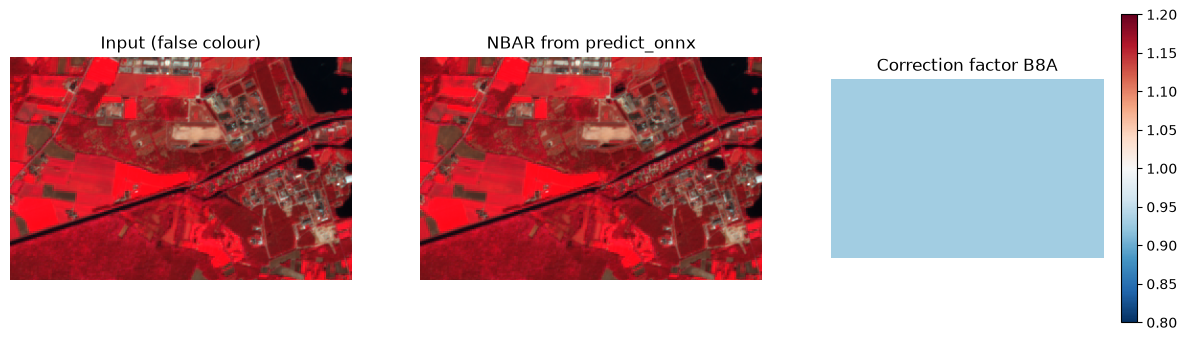

B02: mean correction factor 0.9337
B03: mean correction factor 0.9115
B04: mean correction factor 0.9143
B8A: mean correction factor 0.9305
B11: mean correction factor 0.9159
B12: mean correction factor 0.9080


In [14]:
before, after = read(input_files[0])[0:6], read(onnx_files[0])


def false_color(a):  # B8A, B04, B03
    rgb = a[[3, 2, 1]].transpose(1, 2, 0)
    return np.clip(rgb / np.percentile(rgb, 98), 0, 1)


fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(false_color(before)); ax[0].set_title("Input (false colour)")
ax[1].imshow(false_color(after)); ax[1].set_title("NBAR from predict_onnx")
ratio = np.divide(after[3], before[3], out=np.ones_like(after[3]), where=before[3] > 0)
im = ax[2].imshow(ratio, cmap="RdBu_r", vmin=0.8, vmax=1.2); ax[2].set_title("Correction factor B8A")
fig.colorbar(im, ax=ax[2])
for a in ax:
    a.axis("off")
plt.show()

valid = before > 0
for i, b in enumerate(BAND_ORDER):
    print(f"{b}: mean correction factor {np.mean(after[i][valid[i]] / before[i][valid[i]]):.4f}")

## Pitfalls

- **Band order is positional.** Loading the bands in another order gives wrong numbers
  without any error.
- **Input type must match the data.** Sentinel-2 L2A tiles arrive as float64, so the model
  input is float64.
- **Fixed tile size.** The backend cuts the datacube into tiles of the size declared by the
  model (here 32x32).
- **No `context` in `predict_onnx`.** Per-scene values such as `theta_s` travel as an extra band.
- **`Clip` only takes single-number limits.** Use `maximum`/`minimum` for per-pixel limits.
- **ONNX opset.** ndonnx writes opset 21, which needs ONNX Runtime 1.18 or newer locally
  (the CDSE backend supports it).
- **ONNX Runtime coverage.** Some operators have no float64 implementation; cast to float32
  around them as done here.

## References

- Roy, D. P. et al. (2016). A general method to normalize Landsat reflectance data to nadir
  BRDF adjusted reflectance. *Remote Sensing of Environment*, 176, 255-271.
- Roy, D. P. et al. (2017). Examination of Sentinel-2A multi-spectral instrument (MSI)
  reflectance anisotropy and the suitability of a general method to normalize MSI reflectance
  to nadir BRDF adjusted reflectance. *Remote Sensing of Environment*, 199, 25-38.
- sen2like `S2L_Nbar.py`: https://github.com/senbox-org/sen2like
- Other ways to build the same model (raw ONNX, PyTorch, ONNX Script):
  https://github.com/minaskar/openeo-brdf-onnx